# Amina Hargrove

- **Role:** Data Steward
- **Dataset:** MTA Ridership

In [16]:
%run api.ipynb

<class 'pandas.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 15 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   date                                                  1776 non-null   datetime64[us]
 1   subways_total_estimated_ridership                     1776 non-null   int64         
 2   subways_of_comparable_pre_pandemic_day                1776 non-null   float64       
 3   buses_total_estimated_ridersip                        1776 non-null   int64         
 4   buses_of_comparable_pre_pandemic_day                  1776 non-null   float64       
 5   lirr_total_estimated_ridership                        1776 non-null   int64         
 6   lirr_of_comparable_pre_pandemic_day                   1776 non-null   float64       
 7   metro_north_total_estimated_ridership                 1776 non-null   int64         
 8  

In [17]:

import matplotlib.pyplot as plt


# Weekday vs Weekend Bus Ridership Comparison
- **Independent Variable:** Weekday vs Weekend
- **Dependent Variable:** Average Bus Ridership


- **Key Points:**
    - Groups all 5 weekdays together vs Saturday and Sunday
    - A smaller gap here compared to the subway would suggest buses serve more essential/local trips
    - Helps identify whether bus riders are mostly commuters or everyday riders


In [ ]:
import pandas as pd  # pandas for data manipulation

Average Weekday Bus Ridership: 1,156,554
Average Weekend Bus Ridership: 648,118


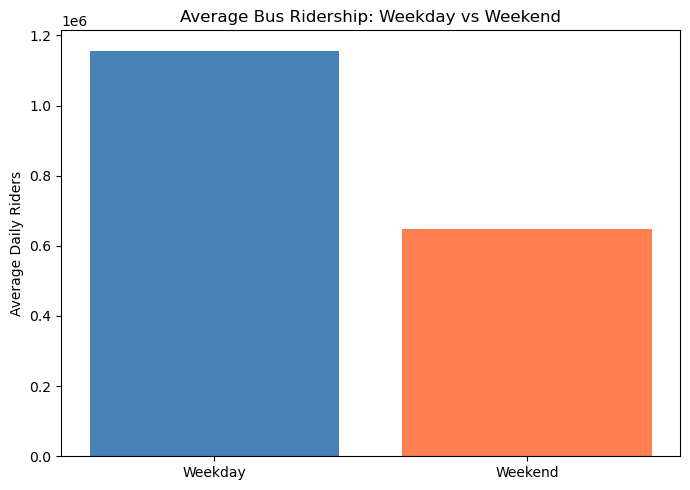

In [45]:
plt.style.use('default')  # set a clean style for the plot

# Extract day of week from date
df['day_of_week'] = df['date'].dt.day_name()  # get weekday names from timestamps

# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']  # preserve natural weekday order

avg_by_day = df.groupby('day_of_week')['buses_total_estimated_ridersip'].mean().reindex(day_order)  # compute average ridership by day, then reorder

# Create a weekend flag
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])  # mark weekends

avg_weekday = df[df['is_weekend'] == False]['buses_total_estimated_ridersip'].mean()  # mean ridership on weekdays
avg_weekend = df[df['is_weekend'] == True]['buses_total_estimated_ridersip'].mean()  # mean ridership on weekends

print(f'Average Weekday Bus Ridership: {avg_weekday:,.0f}')  # display weekday average
print(f'Average Weekend Bus Ridership: {avg_weekend:,.0f}')  # display weekend average

plt.figure(figsize=(7, 5))  # set up figure size
plt.bar(['Weekday', 'Weekend'], [avg_weekday, avg_weekend], color=['steelblue', 'coral'])  # plot comparison bars
plt.title('Average Bus Ridership: Weekday vs Weekend')  # title the chart
plt.ylabel('Average Daily Riders')  # label y-axis
plt.tight_layout()  # improve layout spacing
plt.show()  # render the chart


Bus ridership is higher on weekdays than weekends, but the gap is smaller than what we see with the subway. This suggests that while buses do serve commuters, they also carry a larger share of essential and neighborhood riders who travel on weekends too.

# 7-Day Rolling Average of Bus Ridership
- **Independent Variable:** Date
- **Dependent Variable:** Bus Ridership (smoothed)
- **Key Points:**
    - The 7-day rolling average removes the noise from daily ups and downs
    - Makes it easier to see the overall trend of recovery after the pandemic
    - The weekly cycle (weekday vs weekend dips) becomes less distracting

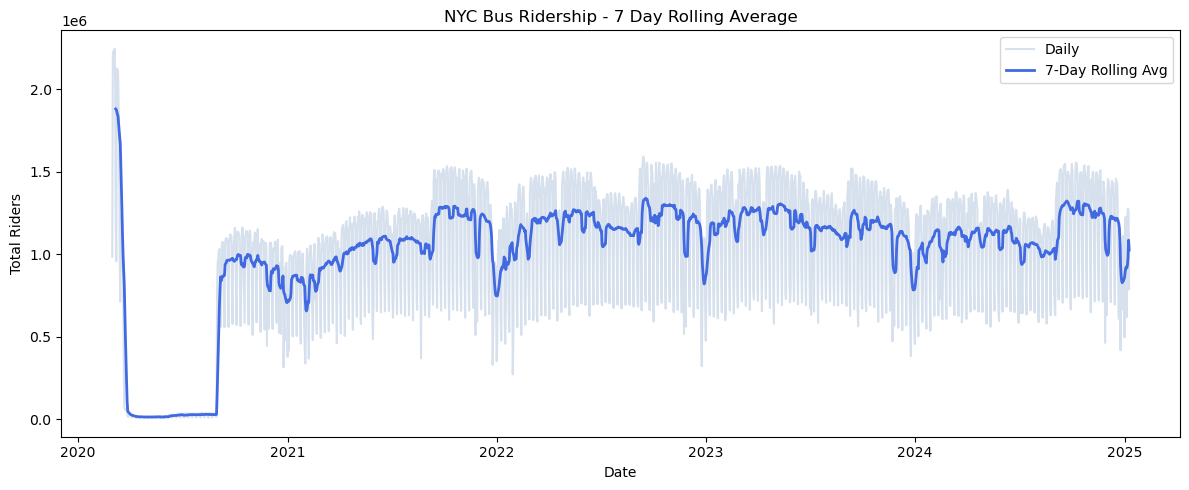

In [25]:
# Calculate the 7-day rolling average of bus ridership

df['bus_rolling_avg'] = df['buses_total_estimated_ridersip'].rolling(window=7).mean()  # smooth daily values over one week

plt.figure(figsize=(12, 5))  # set figure size for the line chart
plt.plot(df['date'], df['buses_total_estimated_ridersip'], color='lightsteelblue', alpha=0.5, label='Daily')  # plot raw daily ridership
plt.plot(df['date'], df['bus_rolling_avg'], color='royalblue', linewidth=2, label='7-Day Rolling Avg')  # plot smoothed trend
plt.title('NYC Bus Ridership - 7 Day Rolling Average')  # chart title
plt.xlabel('Date')  # x-axis label
plt.ylabel('Total Riders')  # y-axis label
plt.legend()  # add legend to distinguish lines
plt.tight_layout()  # adjust layout
plt.show()  # display the plot

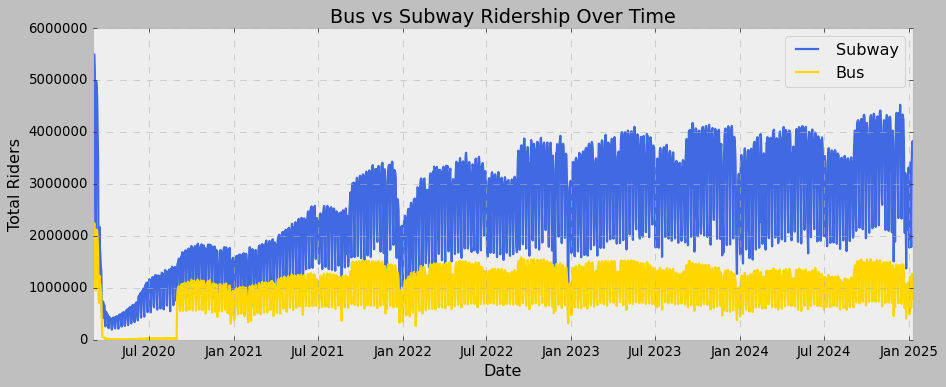

In [43]:
plt.style.use('bmh')  # set a clean style for the plot

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['subways_total_estimated_ridership'], color='royalblue', label='Subway')
plt.plot(df['date'], df['buses_total_estimated_ridersip'], color='gold', label='Bus')
plt.title('Bus vs Subway Ridership Over Time')
plt.xlabel('Date')
plt.ylabel('Total Riders')
plt.legend()
plt.tight_layout()
plt.show()


- **Independent Variable:** Date
- **Dependent Variable:** Ridership (Bus and Subway)

***Key Points:***
- Puts bus ridership in context by comparing it to subway ridership
- Both modes follow the same pandemic dip and recovery pattern
- The gap between them shows how much larger subway ridership is